In [ ]:
# Cell 1: setup (local Jupyter GPU, stronger full run)

import os
import math
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import ResNet50_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False
if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("cuda available:", torch.cuda.is_available())
print("device:", DEVICE)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
assert torch.cuda.is_available(), "GPU not available"

CLASS_NAMES = ["SD", "NOR", "MY", "FS", "BP", "BN", "AP"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

RUN_ALL_TASKS = False
SRC_DOMAIN = "WHEAT_R1-14_M600"
TGT_DOMAIN = "WHEAT_R15-18_M600"

# full-data run
QUICK_MODE = False
QUICK_TRAIN_FRAC = 1.00
QUICK_EVAL_FRAC = 1.00
ONLY_VAL_DURING_RUN = False

IMG_SIZE = 224

# keep paper batch sizes
SRC_BATCH_SIZE = 32
TGT_BATCH_SIZE = 64

# safe micro-batches; if your GPU has plenty of memory, you can raise both to 32
SRC_MICRO_BS = 16
TGT_MICRO_BS = 16

NUM_WORKERS = min(8, max(2, (os.cpu_count() or 4) // 2))

# stronger run
PRETRAIN_EPOCHS = 20
ADAPT_EPOCHS = 20

# paper optimizer schedule
LR0 = 0.01
BETA0 = 0.0002
DELTA = 0.75
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4

# paper / CLUST constants
SIGMA = 0.60
RHO = 0.999
LAMBDA_TOTAL = 100.0
OMEGA_FINAL = 0.9996

# stabilized settings to avoid earlier collapse
GAMMA_IM = 1.0
ALPHA_INIT = 0.5
USE_FIXED_ALPHA = True
FIXED_ALPHA = 0.5
ALPHA_MIN = 0.25
ALPHA_MAX = 0.75

EPS = 1e-8
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
SPLIT_DIR = {"train": "Train", "val": "Validation", "test": "Test"}
SPLIT_SUFFIX = {"train": "TRAIN", "val": "VAL", "test": "TEST"}

root = "/home/user4/_GrainSpace/Dataset/GrainSpace_Dataset"
DATASET_ROOT = root
OUTPUT_ROOT = "/home/user4/_GrainSpace/outputs/grainspace_wheat_clust_fullrun"

os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("DATASET_ROOT:", DATASET_ROOT)
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("SRC_DOMAIN:", SRC_DOMAIN)
print("TGT_DOMAIN:", TGT_DOMAIN)
print("NUM_WORKERS:", NUM_WORKERS)
print("PRETRAIN_EPOCHS:", PRETRAIN_EPOCHS)
print("ADAPT_EPOCHS:", ADAPT_EPOCHS)
print("USE_FIXED_ALPHA:", USE_FIXED_ALPHA, "FIXED_ALPHA:", FIXED_ALPHA)
print("GAMMA_IM:", GAMMA_IM)

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 115.1 MB/s eta 0:00:00
Tue Apr  7 10:23:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                   

In [ ]:
# Cell 2: dataset + loaders

def domain_split_folder(dataset_root, domain_core, split):
    return os.path.join(
        dataset_root,
        SPLIT_DIR[split],
        f"{domain_core}_{SPLIT_SUFFIX[split]}"
    )

def build_records(dataset_root, domain_core, split):
    base = domain_split_folder(dataset_root, domain_core, split)
    records = []
    for class_name in CLASS_NAMES:
        class_dir = os.path.join(base, class_name)
        if not os.path.isdir(class_dir):
            continue
        for path in list_images(class_dir):
            records.append({
                "path": path,
                "label": CLASS_TO_IDX[class_name],
                "class_name": class_name,
                "domain": domain_core,
                "split": split,
            })
    return records

def dataset_summary():
    rows = []
    for domain in [SRC_DOMAIN, TGT_DOMAIN]:
        for split in ["train", "val", "test"]:
            recs = build_records(DATASET_ROOT, domain, split)
            row = {"domain": domain, "split": split, "total": len(recs)}
            cnt = {c: 0 for c in CLASS_NAMES}
            for r in recs:
                cnt[r["class_name"]] += 1
            row.update(cnt)
            rows.append(row)
    return pd.DataFrame(rows)

display(dataset_summary())

train_tfms = transforms.Compose([
    transforms.Resize((192, 192)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize((192, 192)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class GrainDataset(Dataset):
    def __init__(self, records, transform):
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        img = Image.open(rec["path"]).convert("RGB")
        img = self.transform(img)
        return img, rec["label"], rec["path"]

def make_loader(records, transform, batch_size, shuffle=False, drop_last=False):
    ds = GrainDataset(records, transform)
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE == "cuda"),
        drop_last=drop_last,
        persistent_workers=(NUM_WORKERS > 0),
    )

def make_task_loaders(src_domain, tgt_domain):
    data = {
        "src_train": build_records(DATASET_ROOT, src_domain, "train"),
        "src_val": build_records(DATASET_ROOT, src_domain, "val"),
        "src_test": build_records(DATASET_ROOT, src_domain, "test"),
        "tgt_train": build_records(DATASET_ROOT, tgt_domain, "train"),
        "tgt_val": build_records(DATASET_ROOT, tgt_domain, "val"),
        "tgt_test": build_records(DATASET_ROOT, tgt_domain, "test"),
    }

    print("samples:")
    for k, v in data.items():
        print(f"{k}: {len(v)}")

    loaders = {
        "src_train": make_loader(data["src_train"], train_tfms, SRC_BATCH_SIZE, shuffle=True, drop_last=True),
        "src_val": make_loader(data["src_val"], eval_tfms, SRC_BATCH_SIZE, shuffle=False),
        "src_test": make_loader(data["src_test"], eval_tfms, SRC_BATCH_SIZE, shuffle=False),
        "tgt_train": make_loader(data["tgt_train"], train_tfms, TGT_BATCH_SIZE, shuffle=True, drop_last=True),
        "tgt_train_eval": make_loader(data["tgt_train"], eval_tfms, TGT_BATCH_SIZE, shuffle=False),
        "tgt_val": make_loader(data["tgt_val"], eval_tfms, TGT_BATCH_SIZE, shuffle=False),
        "tgt_test": make_loader(data["tgt_test"], eval_tfms, TGT_BATCH_SIZE, shuffle=False),
        "raw": data,
    }
    return loaders

,domain,split,total,SD,NOR,MY,FS,BP,BN,AP
0,WHEAT_R1-14_M600,train,11792,272,10160,272,272,272,272,272
1,WHEAT_R1-14_M600,val,2744,34,2540,34,34,34,34,34
2,WHEAT_R1-14_M600,test,2744,34,2540,34,34,34,34,34
3,WHEAT_R15-18_M600,train,6240,960,4480,160,96,64,320,160
4,WHEAT_R15-18_M600,val,323,120,106,20,12,5,40,20
5,WHEAT_R15-18_M600,test,937,120,717,20,12,8,40,20


In [ ]:
# Cell 3: model + CLUST utilities

class CLUSTNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, scale=20.0):
        super().__init__()
        net = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        feat_dim = net.fc.in_features
        net.fc = nn.Identity()
        self.encoder = net
        self.feat_dim = feat_dim
        self.classifier = nn.Linear(feat_dim, num_classes, bias=False)
        self.scale = scale

    def forward_features(self, x):
        f = self.encoder(x)
        return F.normalize(f, dim=1)

    def logits_from_features(self, f):
        w = F.normalize(self.classifier.weight, dim=1)
        return self.scale * (f @ w.t())

    def forward(self, x):
        f = self.forward_features(x)
        return self.logits_from_features(f)

class PrototypeMemory:
    def __init__(self, num_classes, feat_dim, device):
        self.source = torch.zeros(num_classes, feat_dim, device=device)
        self.target = torch.zeros(num_classes, feat_dim, device=device)
        self.joint  = torch.zeros(num_classes, feat_dim, device=device)

        self.tau_s = torch.ones(num_classes, device=device)
        self.tau_t = torch.ones(num_classes, device=device)
        self.tau_j = torch.ones(num_classes, device=device)

    @torch.no_grad()
    def init_from_model(self, model):
        w = F.normalize(model.classifier.weight.detach(), dim=1)
        self.source.copy_(w)
        self.target.copy_(w)
        self.joint.copy_(w)

def build_model():
    return CLUSTNet().to(DEVICE)

def clone_teacher(student):
    teacher = CLUSTNet().to(DEVICE)
    teacher.load_state_dict(student.state_dict())
    teacher.eval()
    for p in teacher.parameters():
        p.requires_grad = False
    return teacher

@torch.no_grad()
def update_teacher(student, teacher, m=RHO):
    for p_t, p_s in zip(teacher.parameters(), student.parameters()):
        p_t.data.mul_(m).add_(p_s.data, alpha=(1.0 - m))

def forward_feats_chunked(model, x, chunk_size):
    outs = []
    for xb in x.split(chunk_size):
        outs.append(model.forward_features(xb))
    return torch.cat(outs, dim=0)

def poly_lr(optimizer, iter_num):
    lr = LR0 * ((1.0 + BETA0 * iter_num) ** (-DELTA))
    for pg in optimizer.param_groups:
        pg["lr"] = lr
    return lr

def batch_class_means(feats, labels, num_classes=NUM_CLASSES):
    feat_dim = feats.size(1)
    means = torch.zeros(num_classes, feat_dim, device=feats.device)
    present = torch.zeros(num_classes, dtype=torch.bool, device=feats.device)
    for c in range(num_classes):
        mask = labels == c
        if mask.any():
            means[c] = F.normalize(feats[mask].mean(dim=0, keepdim=True), dim=1).squeeze(0)
            present[c] = True
    return means, present

@torch.no_grad()
def ema_update_selected(memory, new_values, present_mask, momentum=RHO):
    for c in range(memory.size(0)):
        if present_mask[c]:
            updated = momentum * memory[c] + (1.0 - momentum) * new_values[c]
            memory[c].copy_(F.normalize(updated.view(1, -1), dim=1).squeeze(0))

def cosine_dist_matrix(a, b):
    a = F.normalize(a, dim=1)
    b = F.normalize(b, dim=1)
    return 1.0 - (a @ b.t())

def sqeuclid_cost_matrix(a, b):
    # with normalized features/prototypes, this is proportional to cosine distance
    return ((a[:, None, :] - b[None, :, :]) ** 2).sum(dim=2)

def transport_probs(objects, prototypes, tau_vec):
    d = cosine_dist_matrix(objects, prototypes)
    tau = tau_vec.clamp_min(1e-4).view(1, -1)
    logits = -d / tau
    probs = torch.softmax(logits, dim=1)
    return probs, d

def feature_clustering_transport_loss(target_feats, dest_prototypes, tau_vec):
    probs, _ = transport_probs(target_feats, dest_prototypes, tau_vec)
    cost = sqeuclid_cost_matrix(target_feats, dest_prototypes)
    loss = (probs * cost).sum(dim=1).mean()
    return loss, probs

def prototype_clustering_transport_loss(obj_prototypes, dest_prototypes, tau_vec):
    probs, _ = transport_probs(obj_prototypes, dest_prototypes, tau_vec)
    cost = sqeuclid_cost_matrix(obj_prototypes, dest_prototypes)
    per_class = (probs * cost).sum(dim=1)
    return per_class.mean(), per_class

def symmetric_kl(p, q):
    p = p.clamp_min(EPS)
    q = q.clamp_min(EPS)
    kl_pq = (p * (p.log() - q.log())).sum(dim=1)
    kl_qp = (q * (q.log() - p.log())).sum(dim=1)
    return 0.5 * (kl_pq + kl_qp).mean()

def info_max_loss(probs):
    probs = probs.clamp_min(EPS)
    lent = -(probs * probs.log()).sum(dim=1).mean()
    p_bar = probs.mean(dim=0).clamp_min(EPS)
    ldiv = (p_bar * p_bar.log()).sum()
    return lent + GAMMA_IM * ldiv, lent, ldiv

def dynamic_alpha(lfea, class_sem_losses):
    dA_global = 2.0 * (1.0 - 2.0 * lfea.detach())
    dA_class  = 2.0 * (1.0 - 2.0 * class_sem_losses.detach())

    dA_global = torch.clamp(dA_global, min=0.0)
    dA_class  = torch.clamp(dA_class, min=0.0)

    alpha = 1.0 - dA_global / (dA_global + dA_class.mean() + EPS)
    alpha = torch.clamp(alpha, 0.0, 1.0)

    if torch.isnan(alpha):
        alpha = torch.tensor(ALPHA_INIT, device=lfea.device)

    return alpha

def compute_tau(features, labels, prototypes, prev_tau):
    tau = prev_tau.clone()
    present = torch.zeros(NUM_CLASSES, dtype=torch.bool, device=features.device)

    for c in range(NUM_CLASSES):
        mask = labels == c
        n_c = int(mask.sum().item())
        if n_c > 0:
            present[c] = True
            d2 = ((features[mask] - prototypes[c].view(1, -1)) ** 2).sum(dim=1)
            delta_c = math.sqrt(1.0 / (2.0 * math.pi)) * math.exp(-abs(n_c))
            denom = max(n_c * math.log(n_c + delta_c + 1e-6), 1e-6)
            tau_c = d2.sum() / denom
            tau[c] = tau_c.clamp(min=1e-4, max=10.0)

    return tau, present

@torch.no_grad()
def predict_joint(model, loader, proto_mem, omega=OMEGA_FINAL):
    model.eval()
    y_true, y_pred = [], []

    for x, y, _ in loader:
        x = x.to(DEVICE, non_blocking=True)
        f = forward_feats_chunked(model, x, TGT_MICRO_BS)

        p_s, _ = transport_probs(f, proto_mem.source, proto_mem.tau_s)
        p_t, _ = transport_probs(f, proto_mem.target, proto_mem.tau_t)
        p = (1.0 - omega) * p_s + omega * p_t

        pred = p.argmax(dim=1).cpu().numpy()
        y_true.extend(y.numpy().tolist())
        y_pred.extend(pred.tolist())

    return np.array(y_true), np.array(y_pred)

def metric_dict(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred) * 100.0
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return {
        "accuracy": acc,
        "macro_precision": prec * 100.0,
        "macro_recall": rec * 100.0,
        "macro_f1": f1 * 100.0,
    }

def save_confusion(y_true, y_pred, path, title):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    fig, ax = plt.subplots(figsize=(7, 7))
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.close(fig)

def save_report(y_true, y_pred, path):
    rep = classification_report(
        y_true, y_pred,
        labels=list(range(NUM_CLASSES)),
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )
    pd.DataFrame(rep).T.to_csv(path)

In [ ]:
# Cell 4: training (with best target-val checkpointing)

def predict_head(model, loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y, _ in loader:
            x = x.to(DEVICE, non_blocking=True)
            f = forward_feats_chunked(model, x, TGT_MICRO_BS)
            logits = model.logits_from_features(f)
            pred = logits.argmax(dim=1).cpu().numpy()
            y_true.extend(y.numpy().tolist())
            y_pred.extend(pred.tolist())

    return np.array(y_true), np.array(y_pred)

def pretrain_source(model, src_train_loader, src_val_loader=None):
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=LR0,
        momentum=MOMENTUM,
        weight_decay=WEIGHT_DECAY,
    )
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))
    criterion = nn.CrossEntropyLoss()

    iter_num = 0
    model.train()

    best_state = None
    best_val_f1 = -1.0

    for epoch in range(1, PRETRAIN_EPOCHS + 1):
        running = 0.0
        seen = 0

        for x_s, y_s, _ in tqdm(src_train_loader, desc=f"PRETRAIN {epoch}/{PRETRAIN_EPOCHS}"):
            x_s = x_s.to(DEVICE, non_blocking=True)
            y_s = y_s.to(DEVICE, non_blocking=True)

            lr = poly_lr(optimizer, iter_num)
            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=(DEVICE == "cuda")):
                f_s = forward_feats_chunked(model, x_s, SRC_MICRO_BS)
                logits_s = model.logits_from_features(f_s)
                loss = criterion(logits_s, y_s)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running += loss.item() * x_s.size(0)
            seen += x_s.size(0)
            iter_num += 1

        print(f"[PRETRAIN] epoch {epoch}/{PRETRAIN_EPOCHS} loss={running/max(seen,1):.4f} lr={lr:.6f}")

        if src_val_loader is not None:
            y_val, p_val = predict_head(model, src_val_loader)
            val_metrics = metric_dict(y_val, p_val)
            print(f"[SRC-VAL-HEAD] epoch {epoch}/{PRETRAIN_EPOCHS} acc={val_metrics['accuracy']:.2f} f1={val_metrics['macro_f1']:.2f}")

            if val_metrics["macro_f1"] > best_val_f1:
                best_val_f1 = val_metrics["macro_f1"]
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

def adapt_clust(model, proto_mem, src_train_loader, tgt_train_loader, tgt_val_loader=None):
    teacher = clone_teacher(model)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=LR0,
        momentum=MOMENTUM,
        weight_decay=WEIGHT_DECAY,
    )
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))
    criterion = nn.CrossEntropyLoss()

    iter_num = 0

    best_score = -1.0
    best_epoch = -1
    best_model_state = None
    best_proto_state = None

    for epoch in range(1, ADAPT_EPOCHS + 1):
        model.train()
        teacher.eval()

        src_iter = iter(src_train_loader)
        tgt_iter = iter(tgt_train_loader)

        num_steps = max(len(src_train_loader), len(tgt_train_loader))
        logs = {
            "loss": 0.0, "cls": 0.0, "fea": 0.0, "sem": 0.0,
            "con": 0.0, "im": 0.0, "alpha": 0.0, "kept": 0, "tgt": 0
        }

        for _ in tqdm(range(num_steps), desc=f"ADAPT {epoch}/{ADAPT_EPOCHS}"):
            try:
                x_s, y_s, _ = next(src_iter)
            except StopIteration:
                src_iter = iter(src_train_loader)
                x_s, y_s, _ = next(src_iter)

            try:
                x_t, _, _ = next(tgt_iter)
            except StopIteration:
                tgt_iter = iter(tgt_train_loader)
                x_t, _, _ = next(tgt_iter)

            x_s = x_s.to(DEVICE, non_blocking=True)
            y_s = y_s.to(DEVICE, non_blocking=True)
            x_t = x_t.to(DEVICE, non_blocking=True)

            lr = poly_lr(optimizer, iter_num)
            optimizer.zero_grad(set_to_none=True)

            with torch.no_grad():
                f_t_teacher = forward_feats_chunked(teacher, x_t, TGT_MICRO_BS)
                p_t_src_teacher, _ = transport_probs(f_t_teacher, proto_mem.source, proto_mem.tau_s)
                conf_t, pseudo_t = p_t_src_teacher.max(dim=1)
                mask_t = conf_t >= SIGMA

            with torch.amp.autocast("cuda", enabled=(DEVICE == "cuda")):
                f_s = forward_feats_chunked(model, x_s, SRC_MICRO_BS)
                f_t = forward_feats_chunked(model, x_t, TGT_MICRO_BS)

                logits_s = model.logits_from_features(f_s)
                l_cls = criterion(logits_s, y_s)

                src_means, src_present = batch_class_means(f_s.detach(), y_s.detach(), NUM_CLASSES)

                if mask_t.any():
                    f_t_conf = f_t[mask_t]
                    pseudo_conf = pseudo_t[mask_t]
                    tgt_means, tgt_present = batch_class_means(f_t_conf.detach(), pseudo_conf.detach(), NUM_CLASSES)

                    joint_feats = torch.cat([f_s.detach(), f_t_conf.detach()], dim=0)
                    joint_labels = torch.cat([y_s.detach(), pseudo_conf.detach()], dim=0)
                    joint_means, joint_present = batch_class_means(joint_feats, joint_labels, NUM_CLASSES)
                else:
                    f_t_conf = None
                    pseudo_conf = None
                    tgt_means = proto_mem.target.clone()
                    tgt_present = torch.zeros(NUM_CLASSES, dtype=torch.bool, device=DEVICE)

                    joint_means = src_means.clone()
                    joint_present = src_present.clone()

                with torch.no_grad():
                    ema_update_selected(proto_mem.source, src_means, src_present, momentum=RHO)
                    ema_update_selected(proto_mem.target, tgt_means, tgt_present, momentum=RHO)
                    ema_update_selected(proto_mem.joint, joint_means, joint_present, momentum=RHO)

                    tau_s_new, tau_s_present = compute_tau(f_s.detach(), y_s.detach(), proto_mem.source, proto_mem.tau_s)
                    for c in range(NUM_CLASSES):
                        if tau_s_present[c]:
                            proto_mem.tau_s[c] = 0.9 * proto_mem.tau_s[c] + 0.1 * tau_s_new[c]

                    if mask_t.any():
                        tau_t_new, tau_t_present = compute_tau(f_t_conf.detach(), pseudo_conf.detach(), proto_mem.target, proto_mem.tau_t)
                        for c in range(NUM_CLASSES):
                            if tau_t_present[c]:
                                proto_mem.tau_t[c] = 0.9 * proto_mem.tau_t[c] + 0.1 * tau_t_new[c]

                    joint_feats_tau = f_s.detach() if not mask_t.any() else torch.cat([f_s.detach(), f_t_conf.detach()], dim=0)
                    joint_labels_tau = y_s.detach() if not mask_t.any() else torch.cat([y_s.detach(), pseudo_conf.detach()], dim=0)
                    tau_j_new, tau_j_present = compute_tau(joint_feats_tau, joint_labels_tau, proto_mem.joint, proto_mem.tau_j)
                    for c in range(NUM_CLASSES):
                        if tau_j_present[c]:
                            proto_mem.tau_j[c] = 0.9 * proto_mem.tau_j[c] + 0.1 * tau_j_new[c]

                l_f_s, p_s = feature_clustering_transport_loss(f_t, proto_mem.source, proto_mem.tau_s)
                l_f_t, p_t = feature_clustering_transport_loss(f_t, proto_mem.target, proto_mem.tau_t)
                l_fea = l_f_s + l_f_t

                l_mu_t, per_t = prototype_clustering_transport_loss(proto_mem.target, proto_mem.joint, proto_mem.tau_j)
                l_mu_s, per_s = prototype_clustering_transport_loss(proto_mem.source, proto_mem.joint, proto_mem.tau_j)
                l_sem = l_mu_t + l_mu_s

                class_sem = 0.5 * (per_t + per_s)
                alpha = dynamic_alpha(l_fea, class_sem)
                l_clu = (1.0 - alpha) * l_fea + alpha * l_sem

                p_con_s, _ = transport_probs(f_t_teacher, proto_mem.source, proto_mem.tau_s)
                p_con_t, _ = transport_probs(f_t_teacher, proto_mem.target, proto_mem.tau_t)
                l_con = symmetric_kl(p_con_s, p_con_t)

                l_im, l_ent, l_div = info_max_loss(p_t)

                loss = l_cls + l_clu + LAMBDA_TOTAL * (l_con + l_im)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            update_teacher(model, teacher, m=RHO)

            logs["loss"] += loss.item()
            logs["cls"] += l_cls.item()
            logs["fea"] += l_fea.item()
            logs["sem"] += l_sem.item()
            logs["con"] += l_con.item()
            logs["im"] += l_im.item()
            logs["alpha"] += alpha.item()
            logs["kept"] += int(mask_t.sum().item())
            logs["tgt"] += int(x_t.size(0))

            iter_num += 1

        print(
            f"[ADAPT] epoch {epoch}/{ADAPT_EPOCHS} "
            f"loss={logs['loss']/num_steps:.4f} "
            f"cls={logs['cls']/num_steps:.4f} "
            f"fea={logs['fea']/num_steps:.4f} "
            f"sem={logs['sem']/num_steps:.4f} "
            f"con={logs['con']/num_steps:.4f} "
            f"im={logs['im']/num_steps:.4f} "
            f"alpha={logs['alpha']/num_steps:.4f} "
            f"kept={logs['kept']}/{logs['tgt']} "
            f"lr={lr:.6f}"
        )

        if tgt_val_loader is not None:
            y_val, p_val = predict_joint(model, tgt_val_loader, proto_mem, omega=OMEGA_FINAL)
            val_metrics = metric_dict(y_val, p_val)
            print(f"[VAL-JOINT] epoch {epoch}/{ADAPT_EPOCHS} acc={val_metrics['accuracy']:.2f} f1={val_metrics['macro_f1']:.2f}")

            if val_metrics["macro_f1"] > best_score:
                best_score = val_metrics["macro_f1"]
                best_epoch = epoch
                best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                best_proto_state = {
                    "source": proto_mem.source.detach().cpu().clone(),
                    "target": proto_mem.target.detach().cpu().clone(),
                    "joint": proto_mem.joint.detach().cpu().clone(),
                    "tau_s": proto_mem.tau_s.detach().cpu().clone(),
                    "tau_t": proto_mem.tau_t.detach().cpu().clone(),
                    "tau_j": proto_mem.tau_j.detach().cpu().clone(),
                }

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        proto_mem.source = best_proto_state["source"].to(DEVICE)
        proto_mem.target = best_proto_state["target"].to(DEVICE)
        proto_mem.joint  = best_proto_state["joint"].to(DEVICE)
        proto_mem.tau_s  = best_proto_state["tau_s"].to(DEVICE)
        proto_mem.tau_t  = best_proto_state["tau_t"].to(DEVICE)
        proto_mem.tau_j  = best_proto_state["tau_j"].to(DEVICE)
        print(f"[BEST] restored epoch {best_epoch} with tgt_val_macro_f1={best_score:.2f}")

    return model, proto_mem


RUNNING WHEAT_R1-14_M600 -> WHEAT_R15-18_M600
samples:
src_train: 11792
src_val: 2744
src_test: 2744
tgt_train: 6240
tgt_val: 323
tgt_test: 937
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 111MB/s]


PRETRAIN 1/15:   0%|          | 0/368 [00:00<?, ?it/s]

[PRETRAIN] epoch 1/15 loss=0.2320 lr=0.009483
[SRC-VAL-HEAD] epoch 1/15 acc=96.39 f1=67.01


PRETRAIN 2/15:   0%|          | 0/368 [00:00<?, ?it/s]

...

[ADAPT] epoch 8/10 loss=-19244.1268 cls=0.2832 fea=2.9006 sem=2.4697 con=0.2113 im=-192.6801 alpha=1.0000 kept=0/23552 lr=0.007067
[VAL-JOINT] epoch 8/10 acc=1.55 f1=1.46


ADAPT 9/10:   0%|          | 0/368 [00:00<?, ?it/s]

[ADAPT] epoch 9/10 loss=-19243.8328 cls=0.2777 fea=2.8453 sem=2.3647 con=0.2182 im=-192.6830 alpha=1.0000 kept=0/23552 lr=0.006831
[VAL-JOINT] epoch 9/10 acc=3.41 f1=3.15


ADAPT 10/10:   0%|          | 0/368 [00:00<?, ?it/s]

[ADAPT] epoch 10/10 loss=-19243.5638 cls=0.2642 fea=2.8003 sem=2.2791 con=0.2235 im=-192.6846 alpha=1.0000 kept=0/23552 lr=0.006613
[VAL-JOINT] epoch 10/10 acc=3.10 f1=2.73
[BEST] restored epoch 1 with tgt_val_macro_f1=11.36

Final results:
src_test_head: {'accuracy': 90.88921282798835, 'macro_precision': 17.898843479617845, 'macro_recall': 15.685171706477865, 'macro_f1': 15.677749651490997}
src_test_joint: {'accuracy': 1.749271137026239, 'macro_precision': 5.175679542401728, 'macro_recall': 20.168067226890756, 'macro_f1': 4.118172620633876}
tgt_val_joint: {'accuracy': 15.789473684210526, 'macro_precision': 11.01066157457135, 'macro_recall': 20.15498652291105, 'macro_f1': 11.357354455778294}
tgt_test_joint: {'accuracy': 14.727854855923159, 'macro_precision': 16.906602714056127, 'macro_recall': 22.76698545526997, 'macro_f1': 9.525497153700018}


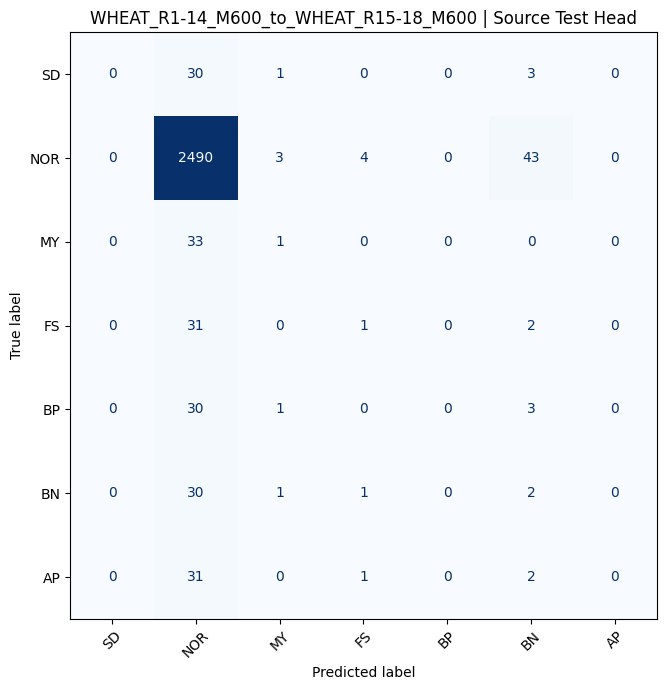

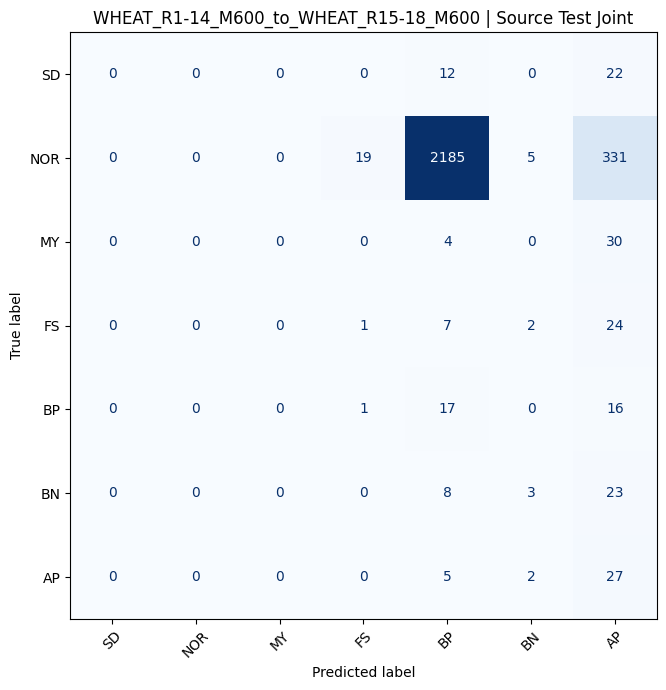

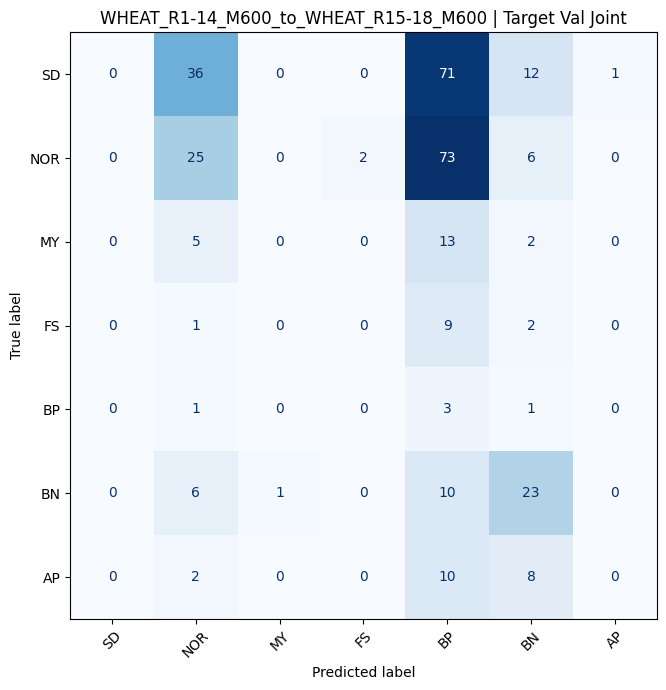

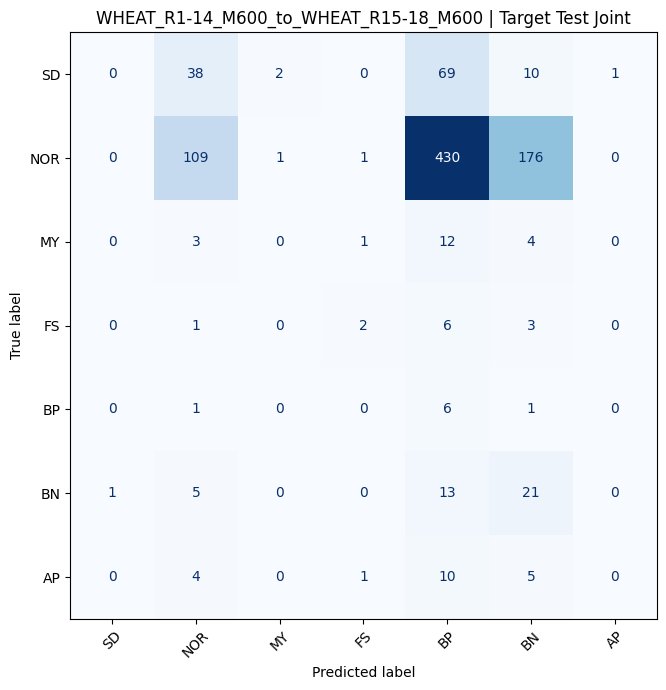

,task,src_test_head_pre_acc,src_test_head_pre_macro_f1,tgt_val_head_pre_acc,tgt_val_head_pre_macro_f1,src_test_head_acc,src_test_head_macro_f1,src_test_joint_acc,src_test_joint_macro_f1,tgt_val_joint_acc,tgt_val_joint_macro_f1,tgt_test_joint_acc,tgt_test_joint_macro_f1
0,WHEAT_R1-14_M600_to_WHEAT_R15-18_M600,96.64723,73.034868,32.817337,7.059607,90.889213,15.67775,1.749271,4.118173,15.789474,11.357354,14.727855,9.525497


Saved to: /content/grainspace_wheat_clust_fast


In [ ]:
# Cell 5: run task(s) + show both source-head and joint metrics

def save_confusion(y_true, y_pred, path, title):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    fig, ax = plt.subplots(figsize=(7, 7))
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def save_report(y_true, y_pred, path):
    rep = classification_report(
        y_true, y_pred,
        labels=list(range(NUM_CLASSES)),
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )
    pd.DataFrame(rep).T.to_csv(path)

def run_task(src_domain, tgt_domain):
    task_name = f"{src_domain}_to_{tgt_domain}"
    task_dir = os.path.join(OUTPUT_ROOT, task_name)
    os.makedirs(task_dir, exist_ok=True)

    loaders = make_task_loaders(src_domain, tgt_domain)

    model = build_model()
    proto_mem = PrototypeMemory(NUM_CLASSES, model.feat_dim, DEVICE)
    proto_mem.init_from_model(model)

    model = pretrain_source(model, loaders["src_train"], loaders["src_val"])
    proto_mem.init_from_model(model)

    # source-only head diagnostics before adaptation
    y_src_head_pre, p_src_head_pre = predict_head(model, loaders["src_test"])
    y_tgt_head_pre, p_tgt_head_pre = predict_head(model, loaders["tgt_val"])
    src_head_pre_metrics = metric_dict(y_src_head_pre, p_src_head_pre)
    tgt_head_pre_metrics = metric_dict(y_tgt_head_pre, p_tgt_head_pre)

    print("\nBefore adaptation:")
    print("src_test_head:", src_head_pre_metrics)
    print("tgt_val_head:", tgt_head_pre_metrics)

    model, proto_mem = adapt_clust(
        model,
        proto_mem,
        loaders["src_train"],
        loaders["tgt_train"],
        tgt_val_loader=loaders["tgt_val"]
    )

    y_src_head, p_src_head = predict_head(model, loaders["src_test"])
    y_src_joint, p_src_joint = predict_joint(model, loaders["src_test"], proto_mem, omega=0.0)
    y_val_joint, p_val_joint = predict_joint(model, loaders["tgt_val"], proto_mem, omega=OMEGA_FINAL)
    y_test_joint, p_test_joint = predict_joint(model, loaders["tgt_test"], proto_mem, omega=OMEGA_FINAL)

    src_head_metrics = metric_dict(y_src_head, p_src_head)
    src_joint_metrics = metric_dict(y_src_joint, p_src_joint)
    val_joint_metrics = metric_dict(y_val_joint, p_val_joint)
    test_joint_metrics = metric_dict(y_test_joint, p_test_joint)

    print("\nFinal results:")
    print("src_test_head:", src_head_metrics)
    print("src_test_joint:", src_joint_metrics)
    print("tgt_val_joint:", val_joint_metrics)
    print("tgt_test_joint:", test_joint_metrics)

    save_confusion(y_src_head, p_src_head, os.path.join(task_dir, "src_test_head_cm.png"), f"{task_name} | Source Test Head")
    save_confusion(y_src_joint, p_src_joint, os.path.join(task_dir, "src_test_joint_cm.png"), f"{task_name} | Source Test Joint")
    save_confusion(y_val_joint, p_val_joint, os.path.join(task_dir, "tgt_val_joint_cm.png"), f"{task_name} | Target Val Joint")
    save_confusion(y_test_joint, p_test_joint, os.path.join(task_dir, "tgt_test_joint_cm.png"), f"{task_name} | Target Test Joint")

    save_report(y_src_head, p_src_head, os.path.join(task_dir, "src_test_head_report.csv"))
    save_report(y_src_joint, p_src_joint, os.path.join(task_dir, "src_test_joint_report.csv"))
    save_report(y_val_joint, p_val_joint, os.path.join(task_dir, "tgt_val_joint_report.csv"))
    save_report(y_test_joint, p_test_joint, os.path.join(task_dir, "tgt_test_joint_report.csv"))

    result = {
        "task": task_name,

        "src_test_head_pre_acc": src_head_pre_metrics["accuracy"],
        "src_test_head_pre_macro_f1": src_head_pre_metrics["macro_f1"],
        "tgt_val_head_pre_acc": tgt_head_pre_metrics["accuracy"],
        "tgt_val_head_pre_macro_f1": tgt_head_pre_metrics["macro_f1"],

        "src_test_head_acc": src_head_metrics["accuracy"],
        "src_test_head_macro_f1": src_head_metrics["macro_f1"],

        "src_test_joint_acc": src_joint_metrics["accuracy"],
        "src_test_joint_macro_f1": src_joint_metrics["macro_f1"],

        "tgt_val_joint_acc": val_joint_metrics["accuracy"],
        "tgt_val_joint_macro_f1": val_joint_metrics["macro_f1"],

        "tgt_test_joint_acc": test_joint_metrics["accuracy"],
        "tgt_test_joint_macro_f1": test_joint_metrics["macro_f1"],
    }

    with open(os.path.join(task_dir, "metrics.json"), "w") as f:
        json.dump(result, f, indent=2)

    torch.save({
        "model_state_dict": model.state_dict(),
        "source_prototypes": proto_mem.source.detach().cpu(),
        "target_prototypes": proto_mem.target.detach().cpu(),
        "joint_prototypes": proto_mem.joint.detach().cpu(),
        "tau_s": proto_mem.tau_s.detach().cpu(),
        "tau_t": proto_mem.tau_t.detach().cpu(),
        "tau_j": proto_mem.tau_j.detach().cpu(),
    }, os.path.join(task_dir, "checkpoint.pt"))

    return result

tasks = [(SRC_DOMAIN, TGT_DOMAIN)]

all_results = []
for s, t in tasks:
    print("\n" + "=" * 100)
    print(f"RUNNING {s} -> {t}")
    print("=" * 100)
    all_results.append(run_task(s, t))

results_df = pd.DataFrame(all_results)
display(results_df)

results_df.to_csv(os.path.join(OUTPUT_ROOT, "all_results.csv"), index=False)
print("Saved to:", OUTPUT_ROOT)